# Section A: Concept Application


1. Fashion MNIST contains raw 28x28 pixel images. Why is Deep Learning more
suitable than traditional ML for classifying raw image data?

Deep Learning is more suitable than traditional Machine Learning for classifying raw 28×28 pixel images in Fashion MNIST because it can automatically learn important features from the image data.

Reasons:

1. Automatic Feature Extraction
Deep Learning models, especially Convolutional Neural Networks (CNNs), automatically detect patterns such as edges, shapes, and textures.
Traditional ML algorithms usually require manual feature engineering before classification.
2. Handles High-Dimensional Data
Each Fashion MNIST image contains 784 pixels (28 × 28).
Deep Learning can efficiently process these large numbers of input features and learn complex relationships between them.
3. Learns Hierarchical Features
Lower layers learn simple features (edges and corners).
Higher layers learn complex features (shirts, shoes, bags, etc.).
Traditional ML models struggle to learn such hierarchical representations directly from raw pixels.
4. Higher Accuracy
CNNs generally achieve better classification performance on image datasets than traditional algorithms such as Logistic Regression, Decision Trees, or KNN when using raw pixel inputs.
5. Robust to Variations
Deep Learning can better handle changes in position, shape, and appearance of objects in images.


2. The DL workflow follows a fixed sequence of stages. List the stages of the Deep
Learning workflow in order.



The standard Deep Learning (DL) workflow follows these stages in order:

1. Data Collection – Gather the required dataset.
2. Data Preprocessing – Clean, normalize, and prepare the data for training.
3. Train-Test Split – Divide data into training, validation, and testing sets.
4. Model Design/Building – Define the neural network architecture.
5. Model Training – Train the model using the training data.
6. Model Validation – Evaluate performance on validation data and tune hyperparameters.
7. Model Testing/Evaluation – Measure final performance on unseen test data.
8. Model Deployment – Deploy the trained model for real-world use.
9. Monitoring and Maintenance – Monitor performance and retrain/update the model when needed.

3. A biological neuron fires only when incoming signals exceed a threshold. What
is the artificial equivalent of this threshold mechanism in a neural network?


The artificial equivalent of a biological neuron's threshold mechanism is the activation function.

How it works:
1. The neuron receives inputs and their corresponding weights.
2. where b is the bias.

3. The result is passed through an activation function (such as ReLU, Sigmoid, or Tanh).
4. The activation function determines whether and how strongly the neuron "fires" (produces an output).

Answer:
In an artificial neural network, the activation function (along with the bias term) serves as the equivalent of the biological neuron's threshold mechanism, deciding whether the neuron becomes activated and passes information forward.

4. You must choose between an ANN and a CNN for Fashion MNIST. What
property of CNNs makes them better suited for image data than a plain ANN?


CNNs are better suited for image data because they use convolutional layers to automatically detect spatial features and local patterns such as edges, textures, and shapes in images.

Why CNNs are better than ANNs for Fashion MNIST:

Preserve spatial relationships between neighboring pixels.
Automatically learn image features without manual feature engineering.
Use shared weights (filters), reducing the number of parameters.
Require less computation and are less prone to overfitting than a fully connected ANN.
Achieve higher accuracy on image classification tasks.

5. Deep Learning was theorized decades ago but became practical only
recently. Name two factors that enabled the rise of modern Deep Learning.

Two major factors that enabled the rise of modern Deep Learning are:

Availability of Large Datasets
The growth of the internet and digital technologies provided massive amounts of labeled data for training deep neural networks.
Examples: ImageNet, Fashion MNIST, and large text datasets.
Increased Computing Power
Powerful GPUs (Graphics Processing Units) and cloud computing made it possible to train deep neural networks efficiently.
Training that once took months can now be completed in hours or days.

# Section B: Practical Task

1. Load the Fashion MNIST dataset and normalize pixel values to a range of [0, 1] using NumPy or TensorFlow.

In [1]:
import pandas as pd
import numpy as np

In [ ]:
# Load CSV files
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

In [ ]:
# Separate features and labels
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

In [ ]:
X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

In [ ]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

In [6]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Training shape: (60000, 784)
Testing shape: (10000, 784)
Min pixel value: 0.0
Max pixel value: 1.0


2. Implement a baseline Artificial Neural Network (ANN) with at least two dense
layers to establish a performance benchmark.

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [8]:
x_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

x_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values


In [9]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


In [ ]:
# Build Baseline ANN Model
model = Sequential([
    Flatten(input_shape=(28, 28)),   # Convert 28x28 image to 784 features
    Dense(128, activation='relu'),   # Hidden Layer 1
    Dense(64, activation='relu'),    # Hidden Layer 2
    Dense(10, activation='softmax')  # Output Layer (10 classes)
])

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
x_train = x_train.reshape(-1, 28, 28)
x_test = x_test.reshape(-1, 28, 28)

In [12]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8163 - loss: 0.5159 - val_accuracy: 0.8593 - val_loss: 0.4053
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8606 - loss: 0.3826 - val_accuracy: 0.8577 - val_loss: 0.3783
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8733 - loss: 0.3435 - val_accuracy: 0.8780 - val_loss: 0.3405
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8823 - loss: 0.3192 - val_accuracy: 0.8766 - val_loss: 0.3390
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8881 - loss: 0.3002 - val_accuracy: 0.8802 - val_loss: 0.3343
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8929 - loss: 0.2867 - val_accuracy: 0.8701 - val_loss: 0.3695
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8978 - loss: 0.2709 - val_accuracy: 0.8788 - val_loss: 0.3366
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9021 - loss: 0.2611 - 

In [15]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8914 - loss: 0.3113
Test Accuracy: 0.8914


3. Design a convolutional Neural Network (CNN) architecture featuring Conv2D,
MaxPooling2D, and Dropout layers for spatial feature extraction.

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.layers import Flatten, Dense

In [17]:
# Reshape data for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [18]:
# CNN Architecture
cnn_model = Sequential([
    
    # Convolution Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # Convolution Block 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(10, activation='softmax')
])

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Compile Model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
# Display Architecture
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

4. Execute a comparative training run for 10 epochs and plot the training vs.
validation accuracy to identify potential overfitting

In [23]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28, 1)
y_train shape: (60000,)


In [24]:
# ANN data
x_train_ann = x_train.reshape(x_train.shape[0], 28, 28)
x_test_ann = x_test.reshape(x_test.shape[0], 28, 28)

# CNN data
x_train_cnn = x_train_ann.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_ann.reshape(-1, 28, 28, 1)

In [25]:
ann_history = model.fit(
    x_train_ann,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

cnn_history = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9124 - loss: 0.2332 - val_accuracy: 0.8900 - val_loss: 0.3327
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9154 - loss: 0.2247 - val_accuracy: 0.8928 - val_loss: 0.3275
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9170 - loss: 0.2199 - val_accuracy: 0.8870 - val_loss: 0.3343
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9193 - loss: 0.2114 - val_accuracy: 0.8855 - val_loss: 0.3359
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9239 - loss: 0.2030 - val_accuracy: 0.8797 - val_loss: 0.3599
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9228 - loss: 0.1994 - val_accuracy: 0.8905 - val_loss: 0.3397
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9290 - loss: 0.1911 - val_accuracy: 0.8868 - val_loss: 0.3521
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9289 - loss: 0.1867 - 

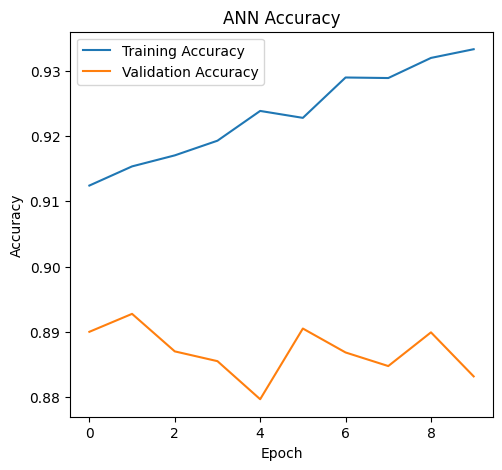

In [26]:
import matplotlib.pyplot as plt
# Plot ANN Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ann_history.history['accuracy'], label='Training Accuracy')
plt.plot(ann_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

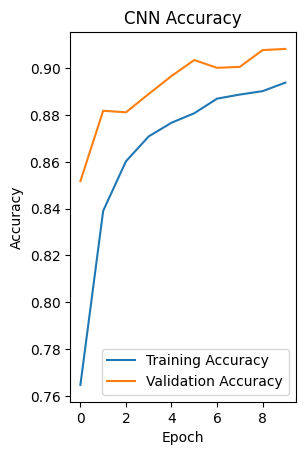

In [27]:
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Section C: Mini Project


1. Title: Fashion-Forward: Automated Inventory Categorization System
2. Problem Statement: Develop an automated visual classification pipeline to
reduce manual tagging errors in a high-volume e-commerce warehouse.
3. Dataset Recommendation: Fashion MNIST (image classification)
4. Required Deliverables: Preprocessing script, CNN Model Architecture Code,
Accuracy/Loss Visualization Plots, Model Evaluation Report (Confusion Matrix).


In [28]:
import pandas as pd
import numpy as np

In [29]:
# Load Fashion MNIST CSV files
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

In [ ]:
# Separate features and labels
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

In [31]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [32]:
# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape: (10000, 28, 28, 1)


In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [35]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])


c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [37]:
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
history = cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.7644 - loss: 0.6431 - val_accuracy: 0.8585 - val_loss: 0.4018
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8390 - loss: 0.4403 - val_accuracy: 0.8805 - val_loss: 0.3360
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8580 - loss: 0.3872 - val_accuracy: 0.8817 - val_loss: 0.3240
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8685 - loss: 0.3627 - val_accuracy: 0.8935 - val_loss: 0.2974
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8755 - loss: 0.3370 - val_accuracy: 0.8970 - val_loss: 0.2820
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8807 - loss: 0.3237 - val_accuracy: 0.8929 - val_loss: 0.2909
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8853 - loss: 0.3118 - val_accuracy: 0.9043 - val_loss: 0.2678
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8891 - lo

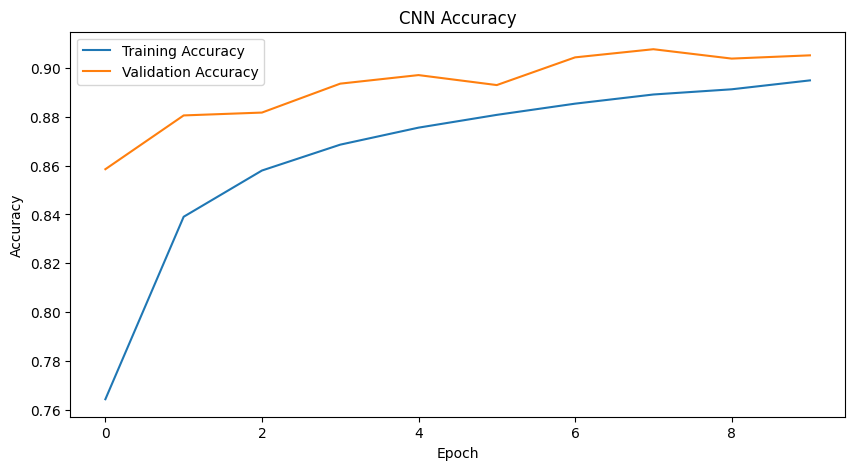

In [39]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


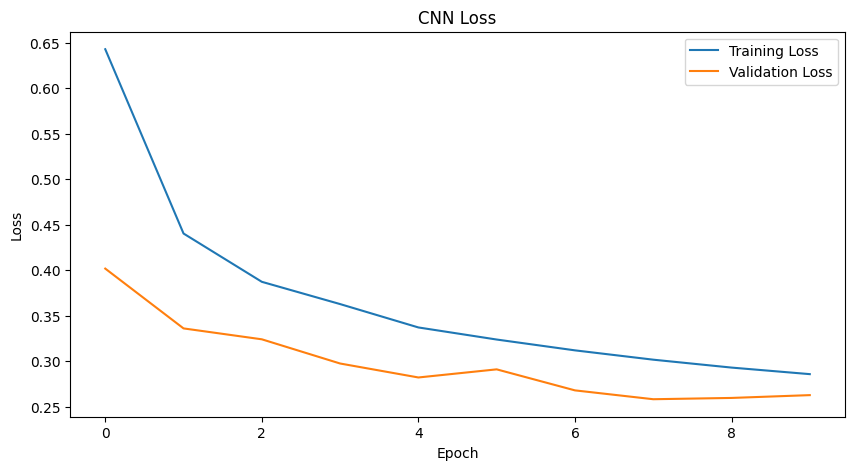

In [40]:
# Loss Plot
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [41]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [42]:
# Predictions
y_pred = cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


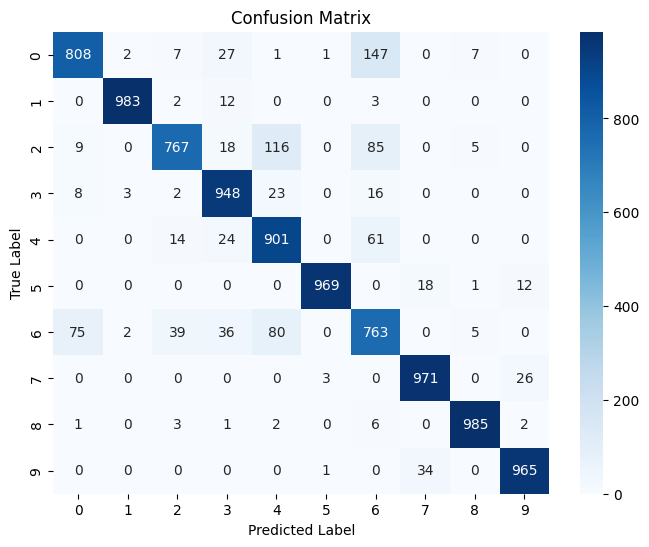

In [43]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [44]:
# Classification Report
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.90      0.81      0.85      1000
           1       0.99      0.98      0.99      1000
           2       0.92      0.77      0.84      1000
           3       0.89      0.95      0.92      1000
           4       0.80      0.90      0.85      1000
           5       0.99      0.97      0.98      1000
           6       0.71      0.76      0.73      1000
           7       0.95      0.97      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

